In [13]:
import zipfile

zip_path = "/content/drive/MyDrive/whu-building-dataset.zip"
extract_path = "/content/WHU_nt"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully")

Unzipped successfully


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
!pip install segmentation-models-pytorch -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.0 MB/s eta 0:00:00


In [6]:
import torch
import torch.nn as nn
import os
import cv2
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import segmentation_models_pytorch as smp
from sklearn.metrics import confusion_matrix

In [7]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

In [9]:
class WHUDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.images = os.listdir(image_dir)
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.images[idx])

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, 0)

        image = cv2.resize(image, (256,256))
        mask = cv2.resize(mask, (256,256))

        image = image / 255.0
        mask = mask / 255.0

        image = torch.tensor(image).permute(2,0,1).float()
        mask = torch.tensor(mask).unsqueeze(0).float()

        return image, mask

In [14]:
train_dataset = WHUDataset(
    "/content/WHU_nt/WHU/train/Image",
    "/content/WHU_nt/WHU/train/Mask"
)

val_dataset = WHUDataset(
    "/content/WHU_nt/WHU/val/Image",
    "/content/WHU_nt/WHU/val/Mask"
)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
)

model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.BCEWithLogitsLoss()

cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

In [15]:
def calculate_metrics(pred, target):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

    pred = pred.view(-1)
    target = target.view(-1)

    TP = (pred * target).sum().item()
    TN = ((1 - pred) * (1 - target)).sum().item()
    FP = (pred * (1 - target)).sum().item()
    FN = ((1 - pred) * target).sum().item()

    epsilon = 1e-7

    accuracy = (TP + TN) / (TP + TN + FP + FN + epsilon)
    precision = TP / (TP + FP + epsilon)
    recall = TP / (TP + FN + epsilon)
    f1 = 2 * precision * recall / (precision + recall + epsilon)
    iou = TP / (TP + FP + FN + epsilon)
    dice = (2 * TP) / (2 * TP + FP + FN + epsilon)

    return accuracy, precision, recall, f1, iou, dice

In [ ]:
pip install tqdm

In [17]:
from tqdm import tqdm

epochs = 10

for epoch in range(epochs):

    print(f"\n========== Epoch {epoch+1}/{epochs} ==========")

    # ----- TRAIN -----
    model.train()
    train_loss = 0

    train_bar = tqdm(train_loader, desc="Training", leave=False)

    for images, masks in train_bar:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        loss = criterion(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        train_bar.set_postfix(loss=loss.item())

    # ----- VALIDATION -----
    model.eval()
    val_loss = 0
    total_metrics = np.zeros(6)

    val_bar = tqdm(val_loader, desc="Validation", leave=False)

    with torch.no_grad():
        for images, masks in val_bar:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)
            val_loss += loss.item()

            metrics = calculate_metrics(outputs, masks)
            total_metrics += np.array(metrics)

    avg_metrics = total_metrics / len(val_loader)

    print("\n----- Epoch Summary -----")
    print(f"Train Loss: {train_loss/len(train_loader):.4f}")
    print(f"Val Loss: {val_loss/len(val_loader):.4f}")
    print(f"Accuracy: {avg_metrics[0]:.4f}")
    print(f"Precision: {avg_metrics[1]:.4f}")
    print(f"Recall: {avg_metrics[2]:.4f}")
    print(f"F1 Score: {avg_metrics[3]:.4f}")
    print(f"IoU: {avg_metrics[4]:.4f}")
    print(f"Dice: {avg_metrics[5]:.4f}")


========== Epoch 1/10 ==========



----- Epoch Summary -----
Train Loss: 0.0935
Val Loss: 0.0937
Accuracy: 0.9625
Precision: 0.8718
Recall: 0.8798
F1 Score: 0.8751
IoU: 0.7788
Dice: 0.8751

========== Epoch 2/10 ==========



----- Epoch Summary -----
Train Loss: 0.0838
Val Loss: 0.0806
Accuracy: 0.9679
Precision: 0.8959
Recall: 0.8882
F1 Score: 0.8919
IoU: 0.8052
Dice: 0.8919

========== Epoch 3/10 ==========



----- Epoch Summary -----
Train Loss: 0.0750
Val Loss: 0.0770
Accuracy: 0.9700
Precision: 0.9108
Recall: 0.8861
F1 Score: 0.8981
IoU: 0.8154
Dice: 0.8981

========== Epoch 4/10 ==========



----- Epoch Summary -----
Train Loss: 0.0713
Val Loss: 0.0771
Accuracy: 0.9694
Precision: 0.8903
Recall: 0.9073
F1 Score: 0.8984
IoU: 0.8160
Dice: 0.8984

========== Epoch 5/10 ==========


...


----- Epoch Summary -----
Train Loss: 0.0656
Val Loss: 0.0732
Accuracy: 0.9714
Precision: 0.9303
Recall: 0.8736
F1 Score: 0.9009
IoU: 0.8200
Dice: 0.9009

========== Epoch 7/10 ==========



----- Epoch Summary -----
Train Loss: 0.0614
Val Loss: 0.0717
Accuracy: 0.9716
Precision: 0.9316
Recall: 0.8739
F1 Score: 0.9016
IoU: 0.8212
Dice: 0.9016

========== Epoch 8/10 ==========



----- Epoch Summary -----
Train Loss: 0.0592
Val Loss: 0.0709
Accuracy: 0.9725
Precision: 0.9083
Recall: 0.9072
F1 Score: 0.9076
IoU: 0.8311
Dice: 0.9076

========== Epoch 9/10 ==========



----- Epoch Summary -----
Train Loss: 0.0565
Val Loss: 0.0744
Accuracy: 0.9715
Precision: 0.9214
Recall: 0.8846
F1 Score: 0.9024
IoU: 0.8225
Dice: 0.9024

========== Epoch 10/10 ==========



----- Epoch Summary -----
Train Loss: 0.0627
Val Loss: 0.0707
Accuracy: 0.9724
Precision: 0.9225
Recall: 0.8904
F1 Score: 0.9059
IoU: 0.8285
Dice: 0.9059


In [18]:
os.makedirs("/content/drive/MyDrive/savedmodels", exist_ok=True)

torch.save(model.state_dict(),
           "/content/drive/MyDrive/savedmodels/deeplabv3plus_whu_10.pth")

print("DeepLabv3+ model saved!")

DeepLabv3+ model saved!


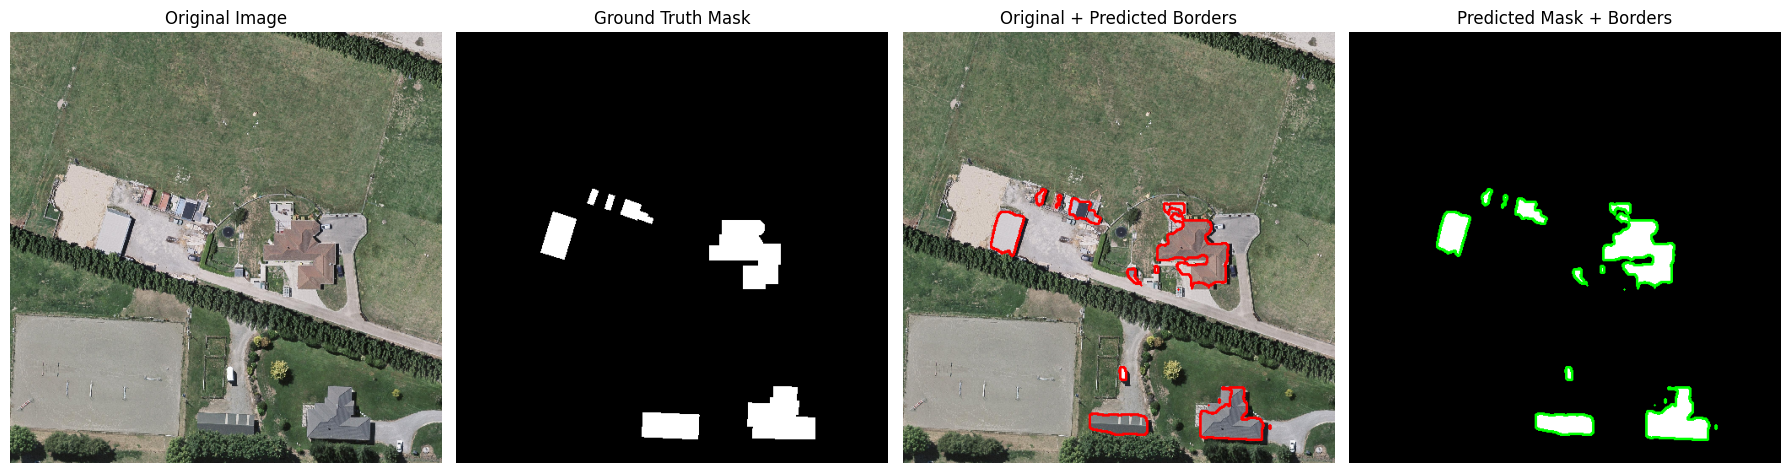

In [24]:
image_path = "/content/WHU_nt/WHU/test/Image/test_0014.png"
mask_path = "/content/WHU_nt/WHU/test/Mask/test_0014.png"

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

gt_mask = cv2.imread(mask_path, 0)

# resize if needed
image = cv2.resize(image, (512,512))
gt_mask = cv2.resize(gt_mask, (512,512))

# normalize
img = image / 255.0

# convert to tensor
img_tensor = torch.tensor(img).permute(2,0,1).unsqueeze(0).float().to(device)


# -------------------------------
# 3. Model Prediction
# -------------------------------
with torch.no_grad():
    output = model(img_tensor)

pred_mask = torch.sigmoid(output).cpu().numpy()[0,0]

# threshold
pred_mask = (pred_mask > 0.5).astype(np.uint8) * 255


# -------------------------------
# 4. Find Contours (Borders)
# -------------------------------
contours, _ = cv2.findContours(
    pred_mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)


# -------------------------------
# 5. Draw Borders on Original Image
# -------------------------------
image_with_borders = image.copy()

cv2.drawContours(
    image_with_borders,
    contours,
    -1,
    (255,0,0),
    2
)


# -------------------------------
# 6. Draw Borders on Predicted Mask
# -------------------------------
pred_mask_color = cv2.cvtColor(pred_mask, cv2.COLOR_GRAY2RGB)

cv2.drawContours(
    pred_mask_color,
    contours,
    -1,
    (0,255,0),
    2
)


# -------------------------------
# 7. Plot Results (4 Panels)
# -------------------------------
plt.figure(figsize=(18,6))

plt.subplot(1,4,1)
plt.title("Original Image")
plt.imshow(image)
plt.axis("off")

plt.subplot(1,4,2)
plt.title("Ground Truth Mask")
plt.imshow(gt_mask, cmap="gray")
plt.axis("off")

plt.subplot(1,4,3)
plt.title("Original + Predicted Borders")
plt.imshow(image_with_borders)
plt.axis("off")

plt.subplot(1,4,4)
plt.title("Predicted Mask + Borders")
plt.imshow(pred_mask_color)
plt.axis("off")

plt.tight_layout()
plt.show()

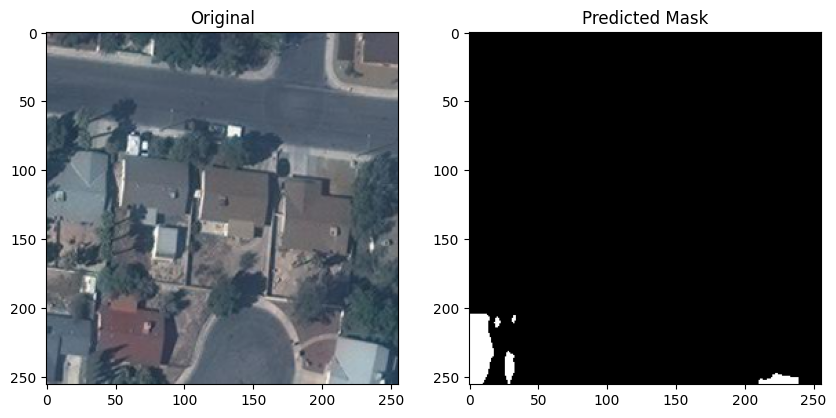

In [20]:
image_path = "/content/000000000016.jpg"

original, predicted_mask = predict_image(image_path, model, device)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(original)
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(predicted_mask, cmap='gray')
plt.title("Predicted Mask")

plt.show()